# Exploratory Data Analysis (EDA)

This notebook analyzes the training dataset containing travel behavior and trip characteristics of tourists.
Our goal is to understand the distribution of variables, identify missing values, explore patterns, and prepare the dataset for machine learning models (Logistic Regression, SVMs, Neural Networks).

### Load the Dataset

In [2]:
import pandas as pd

# Load the datasets
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

train.head()


,trip_id,country,age_group,travel_companions,num_females,num_males,main_activity,visit_purpose,is_first_visit,mainland_stay_nights,...,food_included,domestic_transport_included,sightseeing_included,guide_included,insurance_included,days_booked_before_trip,arrival_weather,total_trip_days,has_special_requirements,spend_category
0,tour_idftaa27vp,FRANCE,45-64,With Spouse and Children,1.0,2.0,Beach Tourism,Leisure and Holidays,Yes,0,...,No,No,No,No,No,NaN,"cloudy,",30+,NaN,1.0
1,tour_iduck75m57,KENYA,45-64,Alone,1.0,0.0,Conference Tourism,Meetings and Conference,Yes,6,...,No,No,No,No,No,15-30,"sunny,",30+,NaN,2.0
2,tour_id8y3w40h8,SOUTH AFRICA,25-44,With Other Friends/Relatives,2.0,0.0,Cultural Tourism,Meetings and Conference,No,4,...,No,No,No,No,No,90+,"sunny,",30+,none,2.0
3,tour_idkoh8mkgr,ITALY,25-44,With Spouse,1.0,1.0,Widlife Tourism,Leisure and Holidays,Yes,0,...,Yes,Yes,Yes,Yes,No,8-14,NaN,NaN,none,0.0
4,tour_idkmsfa00a,ITALY,25-44,With Spouse,1.0,1.0,Beach Tourism,Leisure and Holidays,Yes,0,...,Yes,No,No,No,No,90+,"sunny,",7-14,NaN,0.0


### Dataset Shape & Basic Information

In [3]:
# Check dataset dimensions
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Detailed column info
train.info()

Train shape: (12654, 25)
Test shape: (5852, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12654 entries, 0 to 12653
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trip_id                      12654 non-null  object 
 1   country                      12424 non-null  object 
 2   age_group                    12646 non-null  object 
 3   travel_companions            11917 non-null  object 
 4   num_females                  12652 non-null  float64
 5   num_males                    12650 non-null  float64
 6   main_activity                12526 non-null  object 
 7   visit_purpose                12654 non-null  object 
 8   is_first_visit               12555 non-null  object 
 9   mainland_stay_nights         12654 non-null  int64  
 10  island_stay_nights           12654 non-null  int64  
 11  tour_type                    12654 non-null  object 
 12  intl_transport_included   

### Analysing Missing Values

In [4]:
# Calculate missing values
missing_counts = train.isnull().sum()
missing_percent = (missing_counts / len(train)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent.round(2)
}).sort_values(by="Missing %", ascending=False)

missing_df

,Missing Count,Missing %
has_special_requirements,8117,64.15
arrival_weather,3403,26.89
days_booked_before_trip,1553,12.27
travel_companions,737,5.82
total_trip_days,402,3.18
insurance_included,236,1.87
country,230,1.82
food_included,171,1.35
intl_transport_included,147,1.16
accomodation_included,143,1.13


### Visualizing Missing Values (Heatmap)

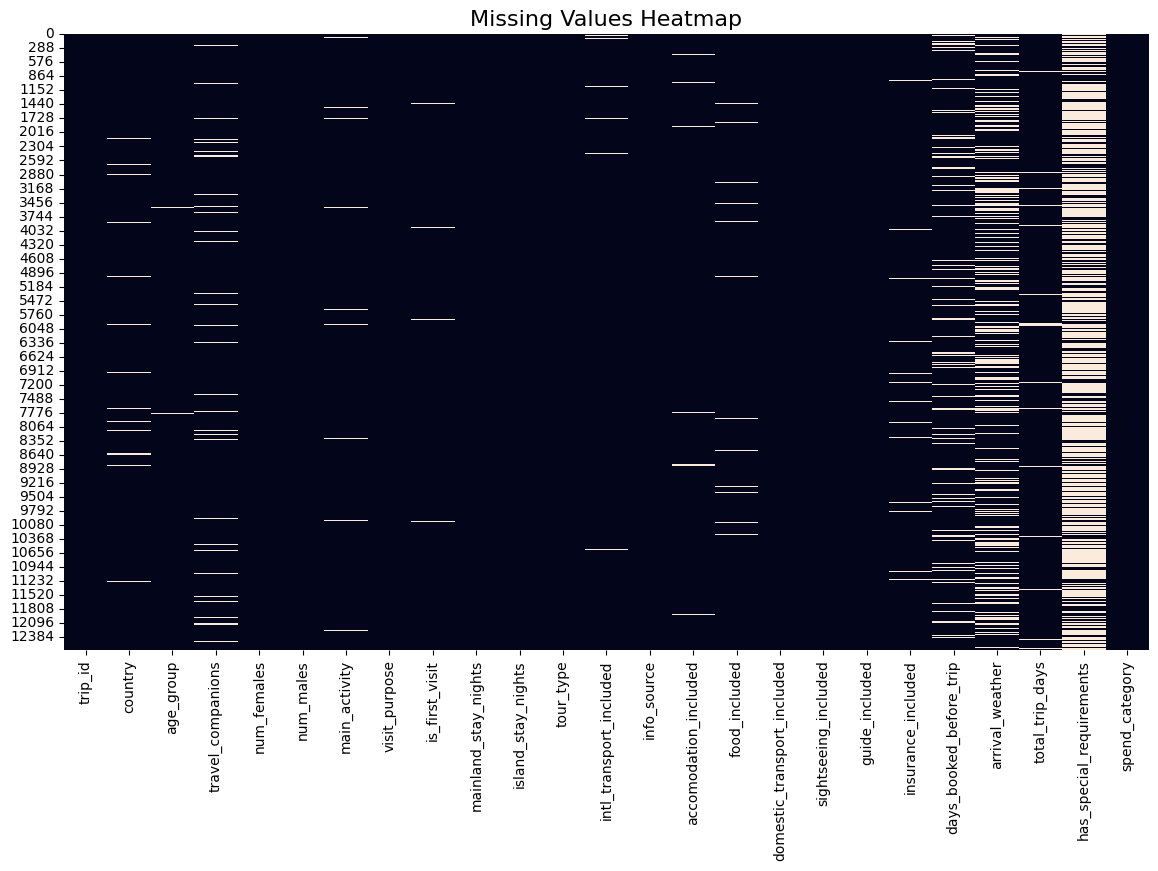

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

### Explore Categorical Features

In [6]:
categorical_cols = [
    "country", "age_group", "travel_companions", "main_activity",
    "visit_purpose", "tour_type", "arrival_weather",
    "total_trip_days", "has_special_requirements"
]

for col in categorical_cols:
    print(f"----- {col} -----")
    print(train[col].value_counts(dropna=False))
    print("\n")


----- country -----
country
UNITED STATES OF AMERICA    1953
UNITED KINGDOM              1415
ITALY                       1125
FRANCE                       738
GERMANY                      655
                            ... 
ESTONIA                        1
NIGER                          1
AFGHANISTAN                    1
DJIBOUT                        1
IRAN                           1
Name: count, Length: 124, dtype: int64


----- age_group -----
age_group
25-44    6146
45-64    3907
18-24    1500
65+      1011
<18        82
NaN         8
Name: count, dtype: int64


----- travel_companions -----
travel_companions
Alone                           5088
With Spouse                     3389
With Other Friends/Relatives    2221
With Spouse and Children         849
NaN                              737
With Children                    370
Name: count, dtype: int64


----- main_activity -----
main_activity
Widlife Tourism             4096
Beach Tourism               2860
Wildlife Tourism    

### Visualizing Key Categorical Variables

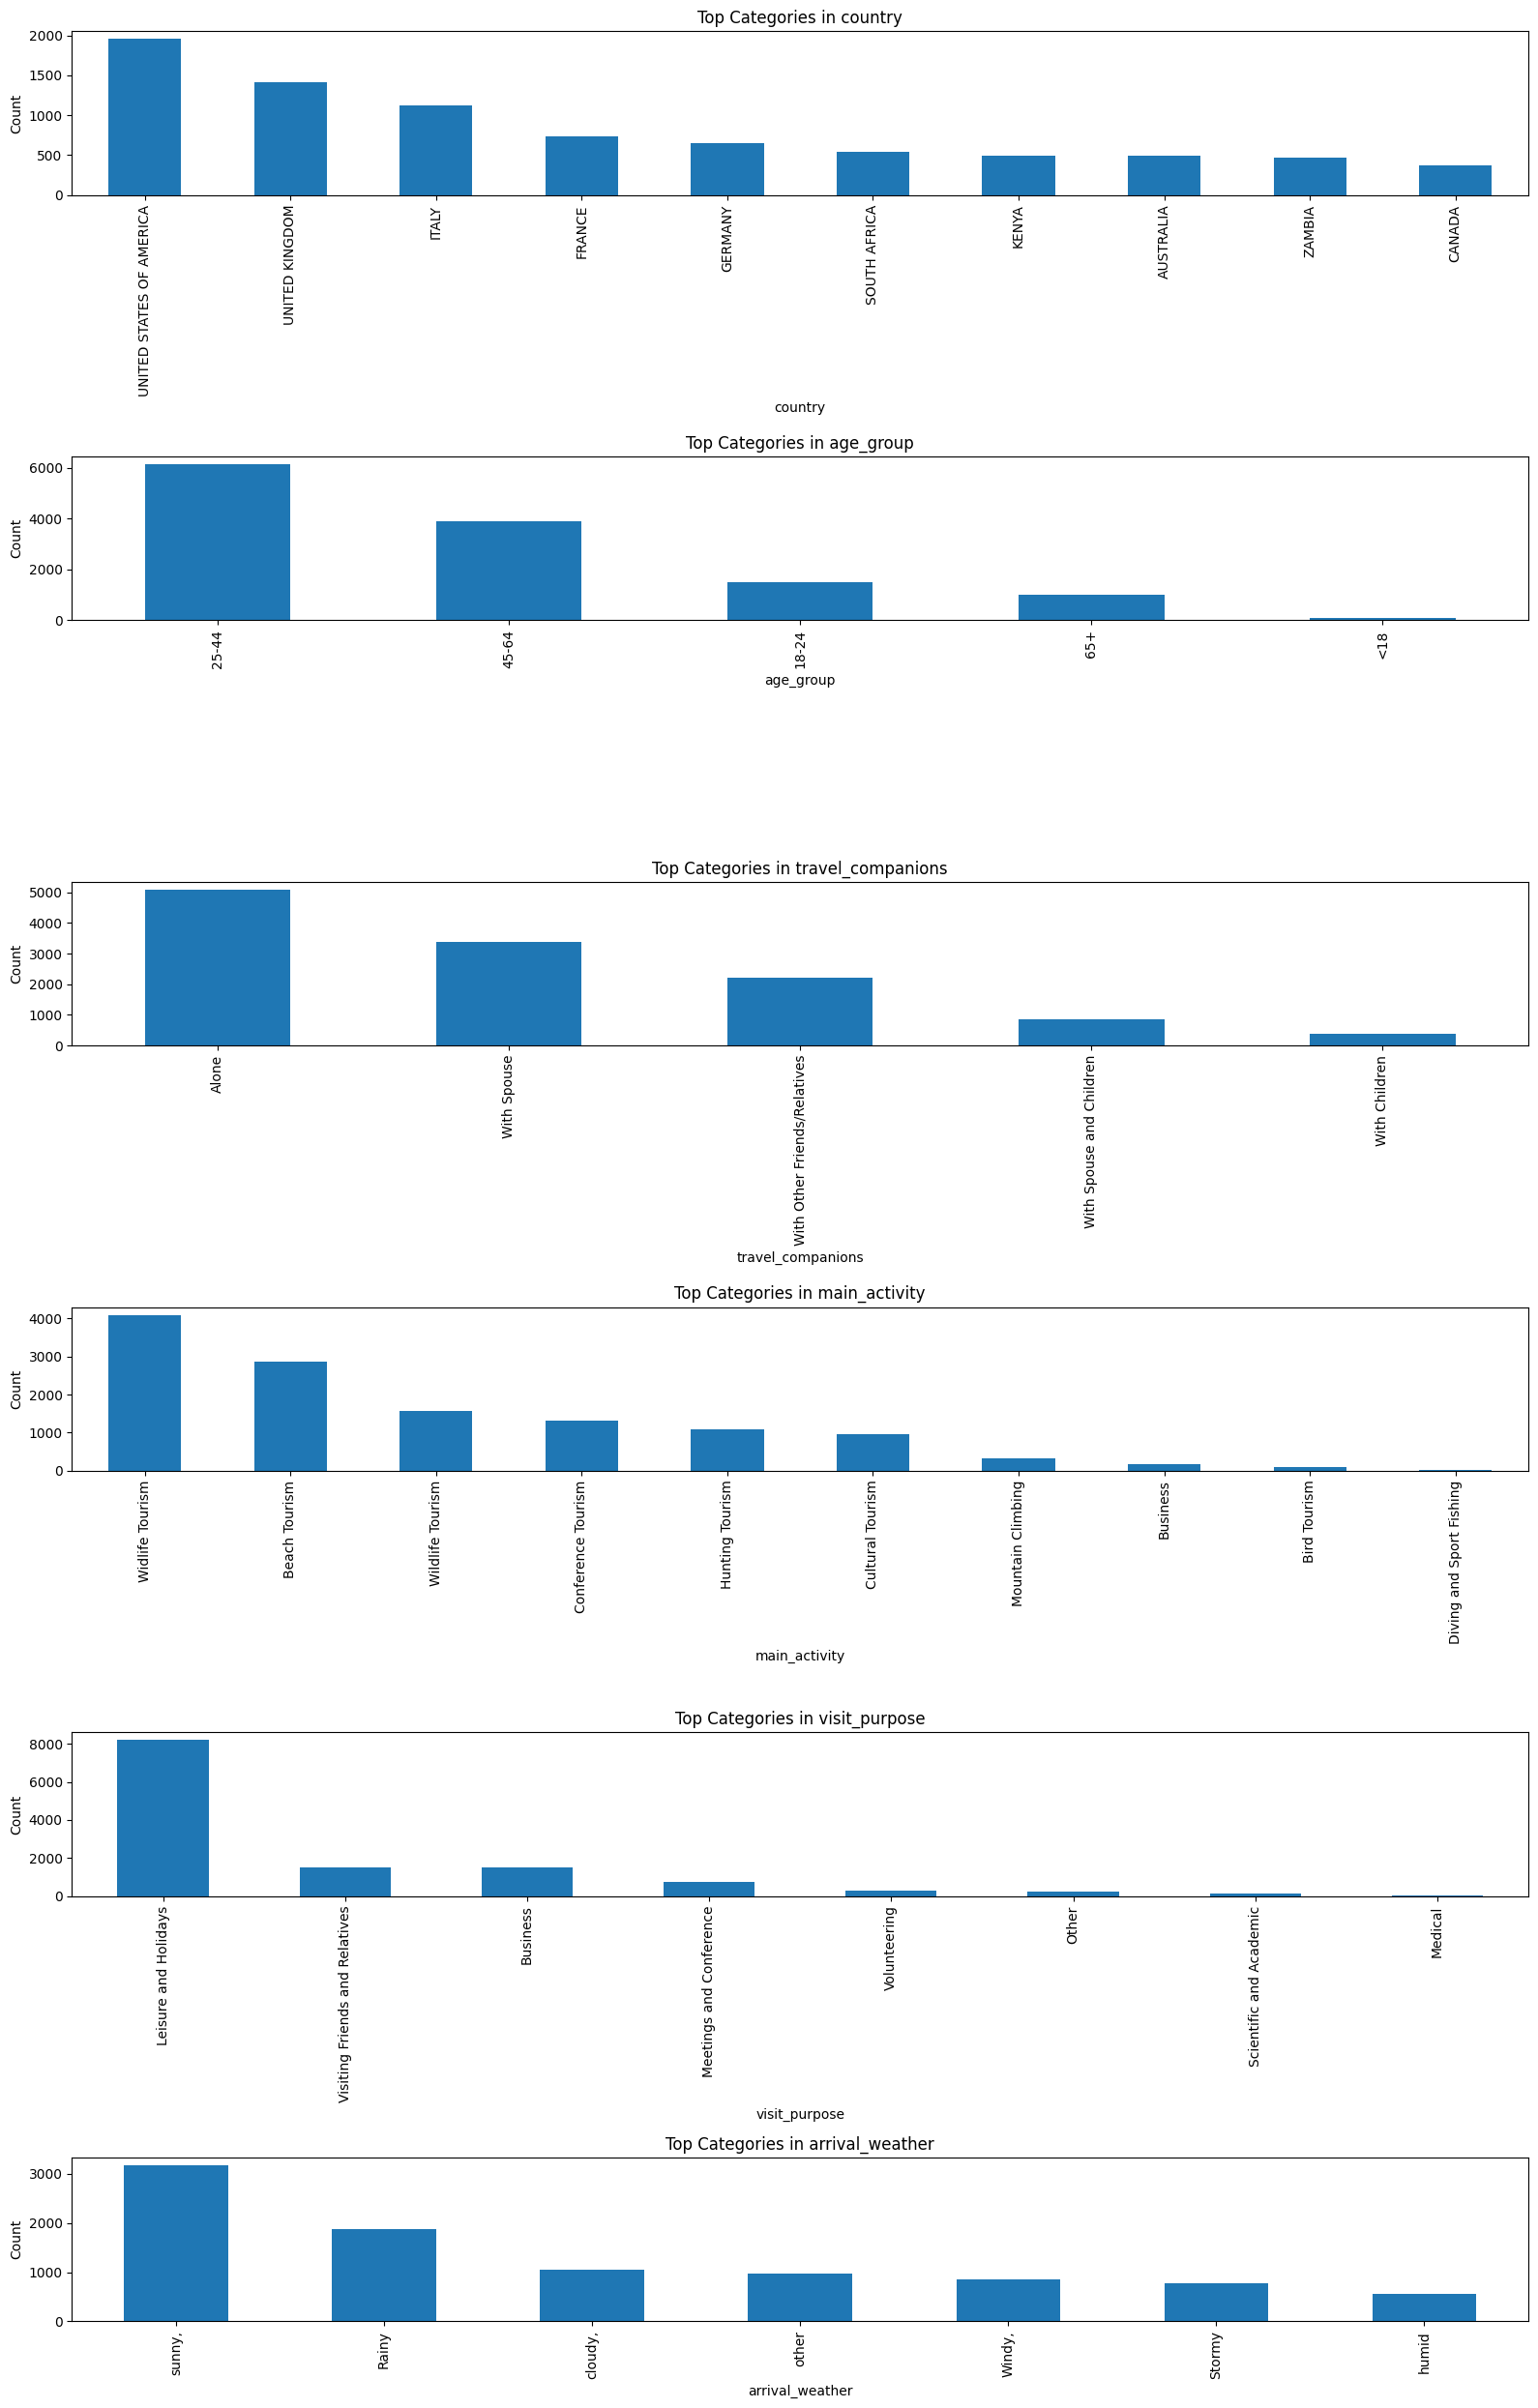

In [10]:
# Selecting a few key categorical columns for plotting
plot_cols = [
    "country",
    "age_group",
    "travel_companions",
    "main_activity",
    "visit_purpose",
    "arrival_weather"
]

plt.figure(figsize=(16, 25))

for i, col in enumerate(plot_cols, 1):
    plt.subplot(len(plot_cols), 1, i)
    train[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Numerical Feature Exploration using BoxPlots

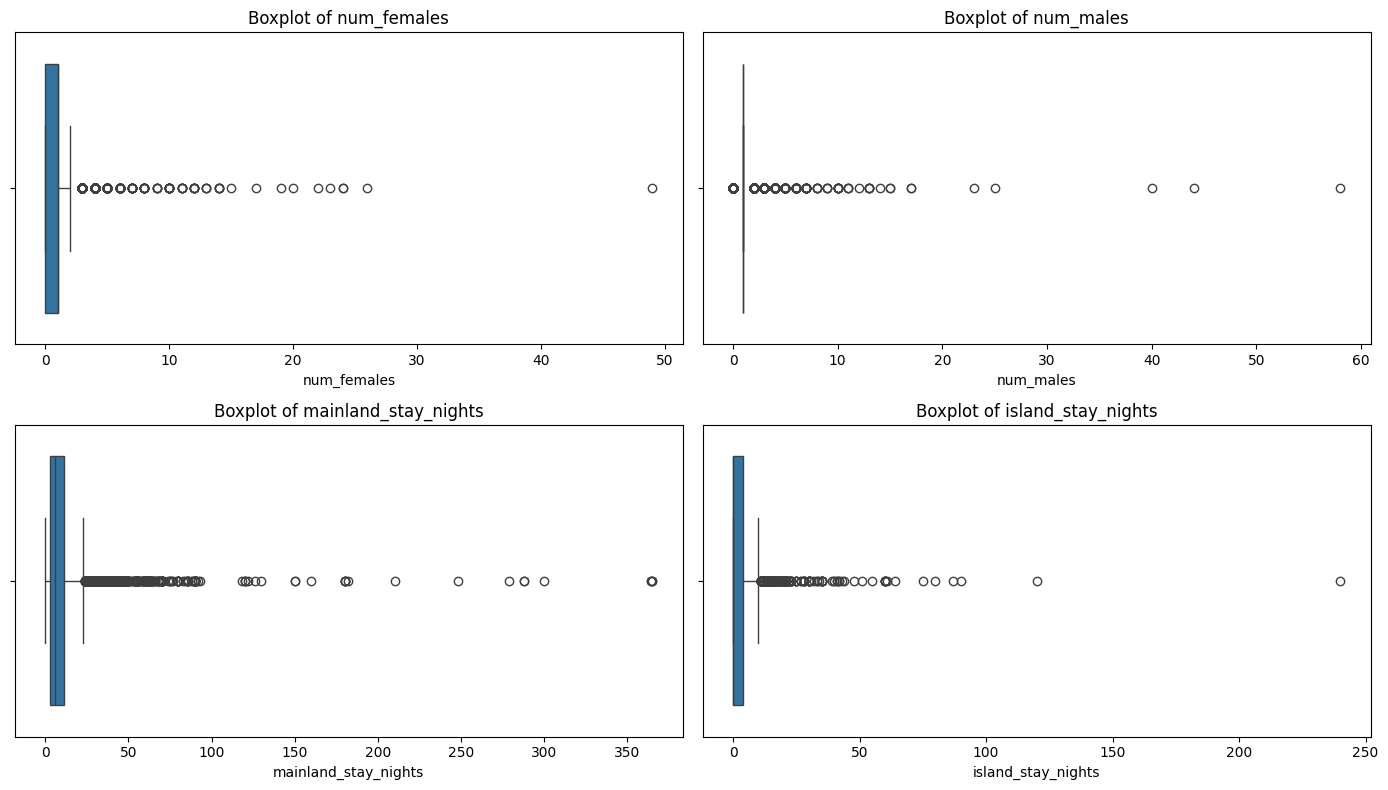

In [9]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=train[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### Target Variable Analysis

Spend Category Value Counts:
spend_category
0.0    6245
1.0    4911
2.0    1464
NaN      34
Name: count, dtype: int64


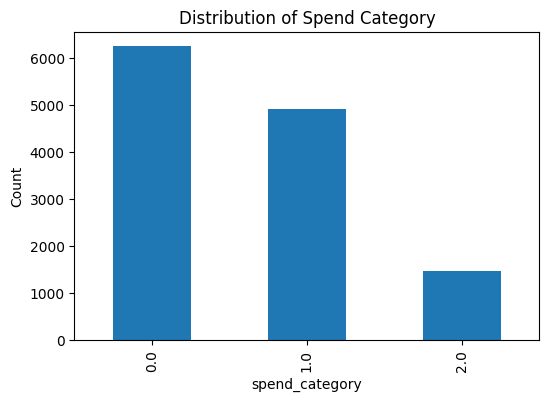

In [12]:
print("Spend Category Value Counts:")
print(train["spend_category"].value_counts(dropna=False))

# Plot distribution
plt.figure(figsize=(6,4))
train["spend_category"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Spend Category")
plt.xlabel("spend_category")
plt.ylabel("Count")
plt.show()

### Bivariate Analysis (Categorical vs Target)

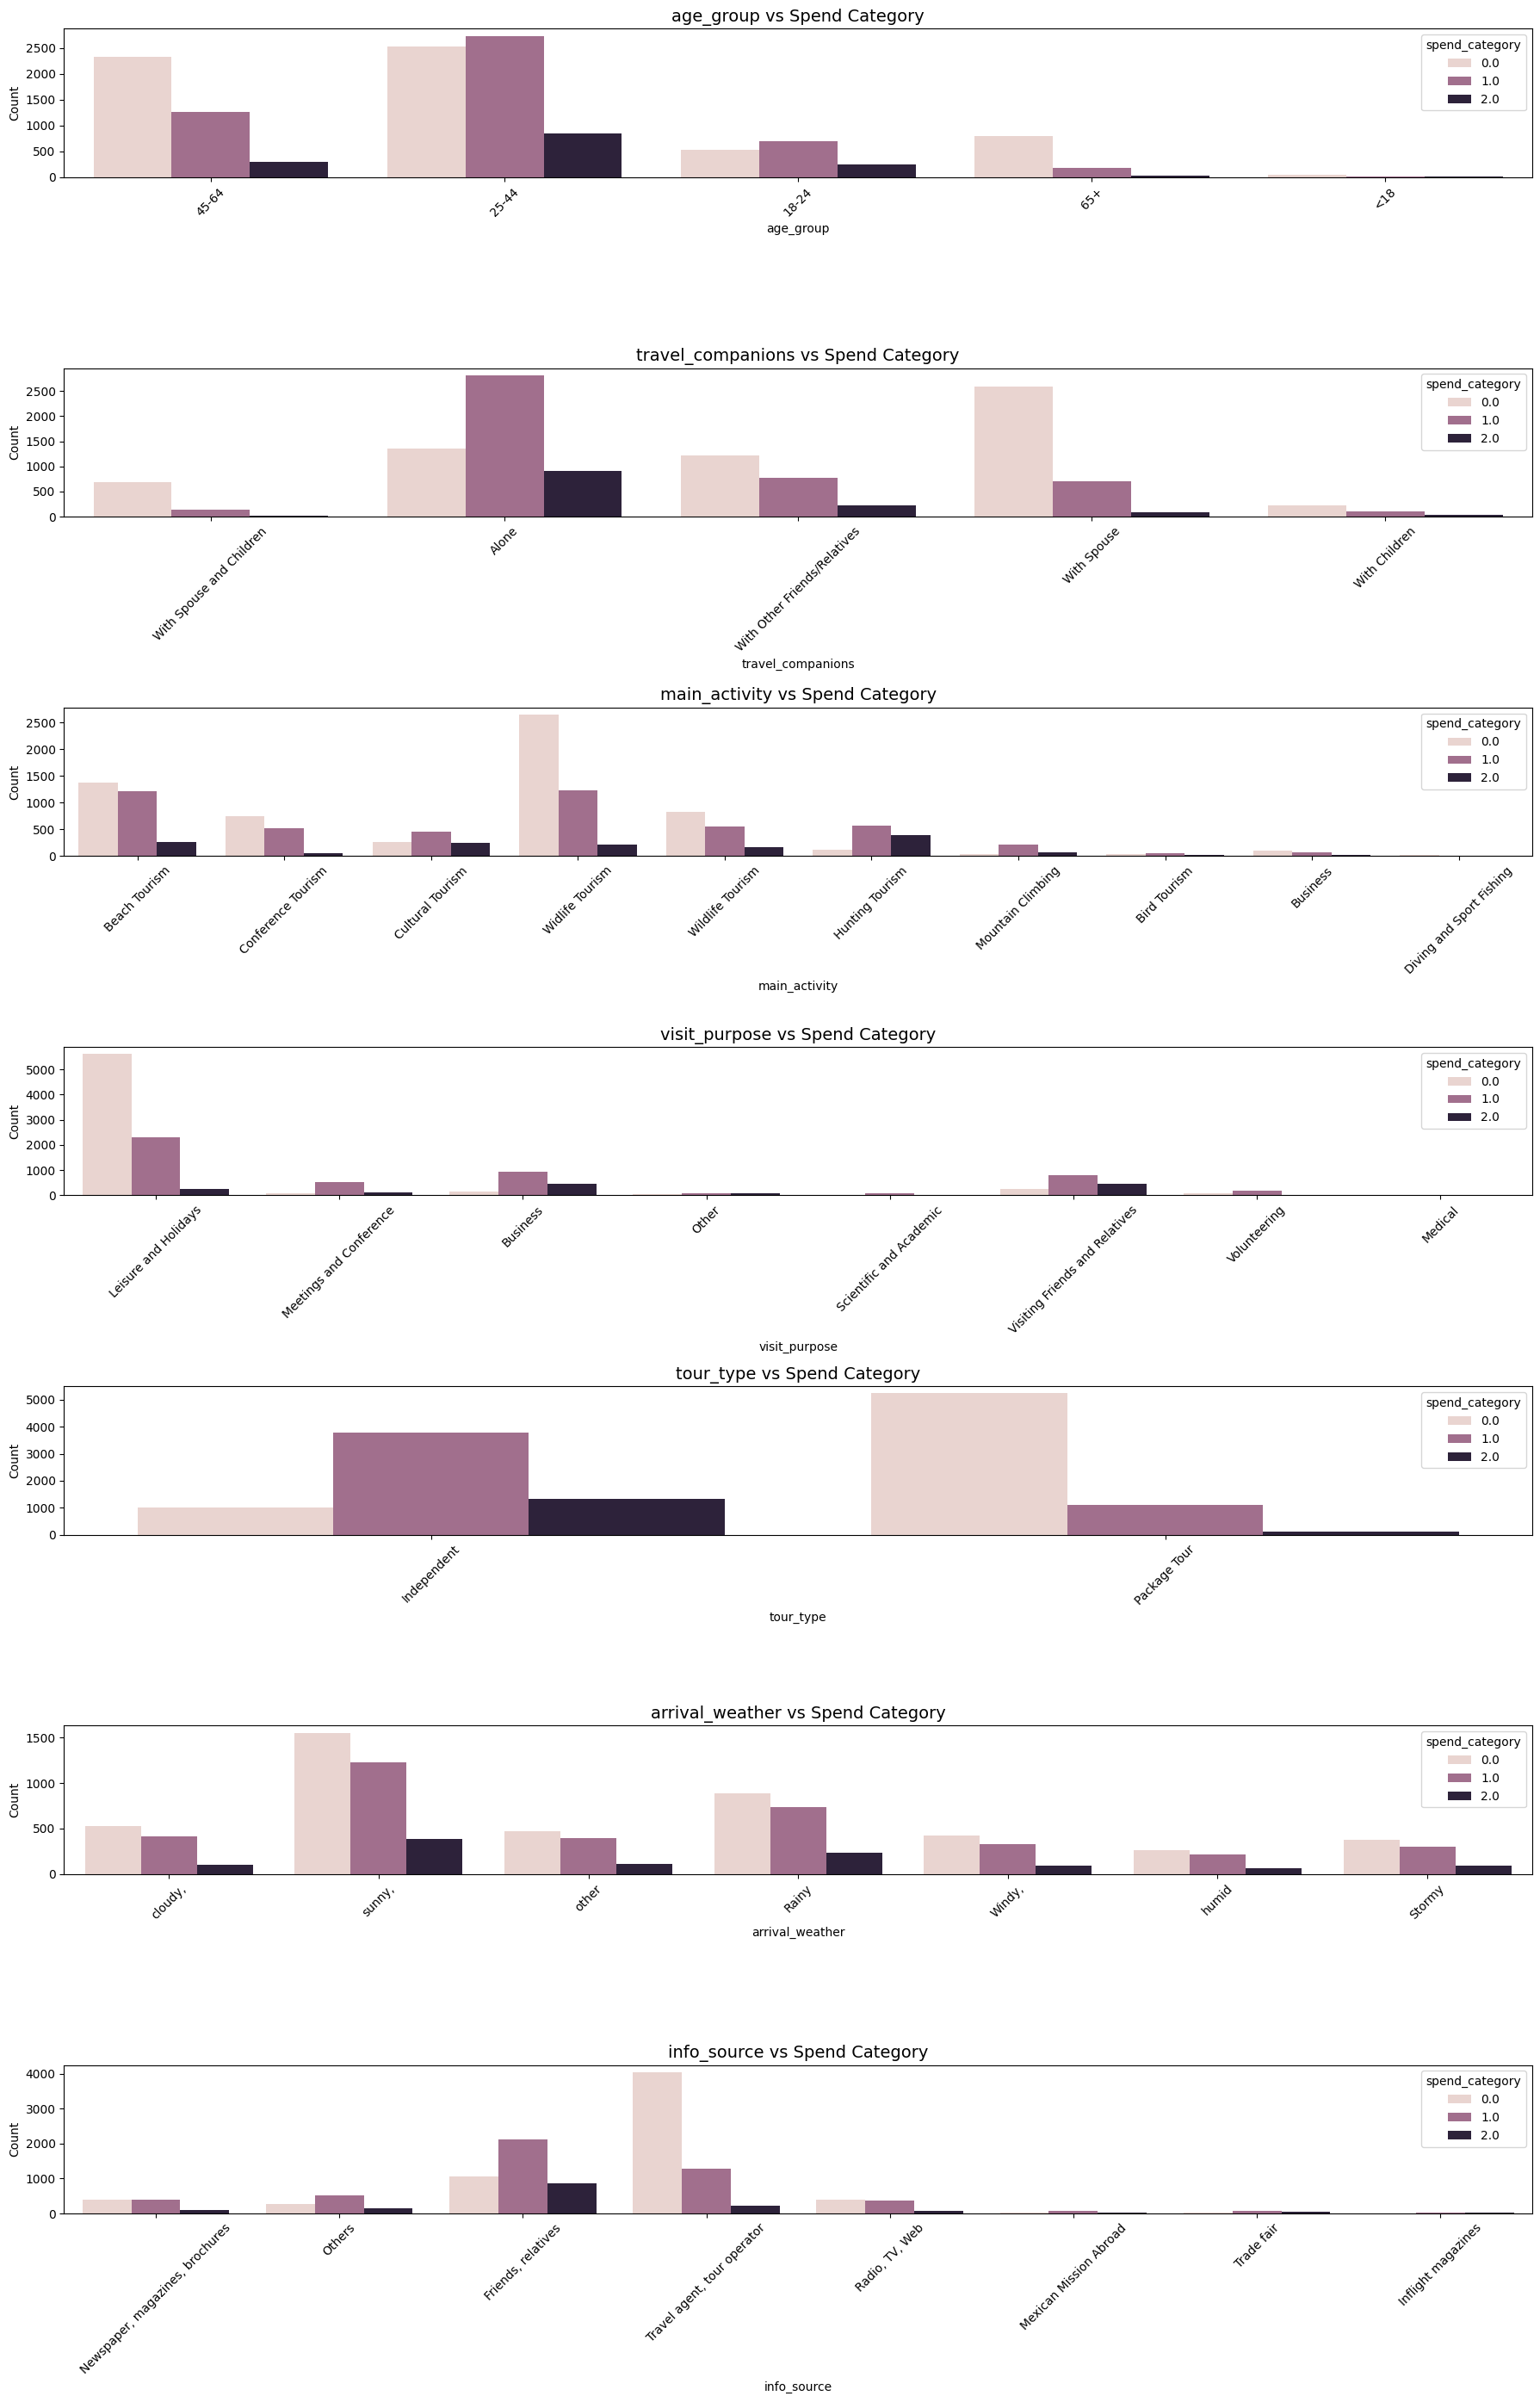

In [17]:
categorical_cols = [
    "age_group",
    "travel_companions",
    "main_activity",
    "visit_purpose",
    "tour_type",
    "arrival_weather",
    "info_source"
]

plt.figure(figsize=(18, 28))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(data=train, x=col, hue="spend_category")
    plt.title(f"{col} vs Spend Category", fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()



### Bivariate Analysis (Numerical vs Target)

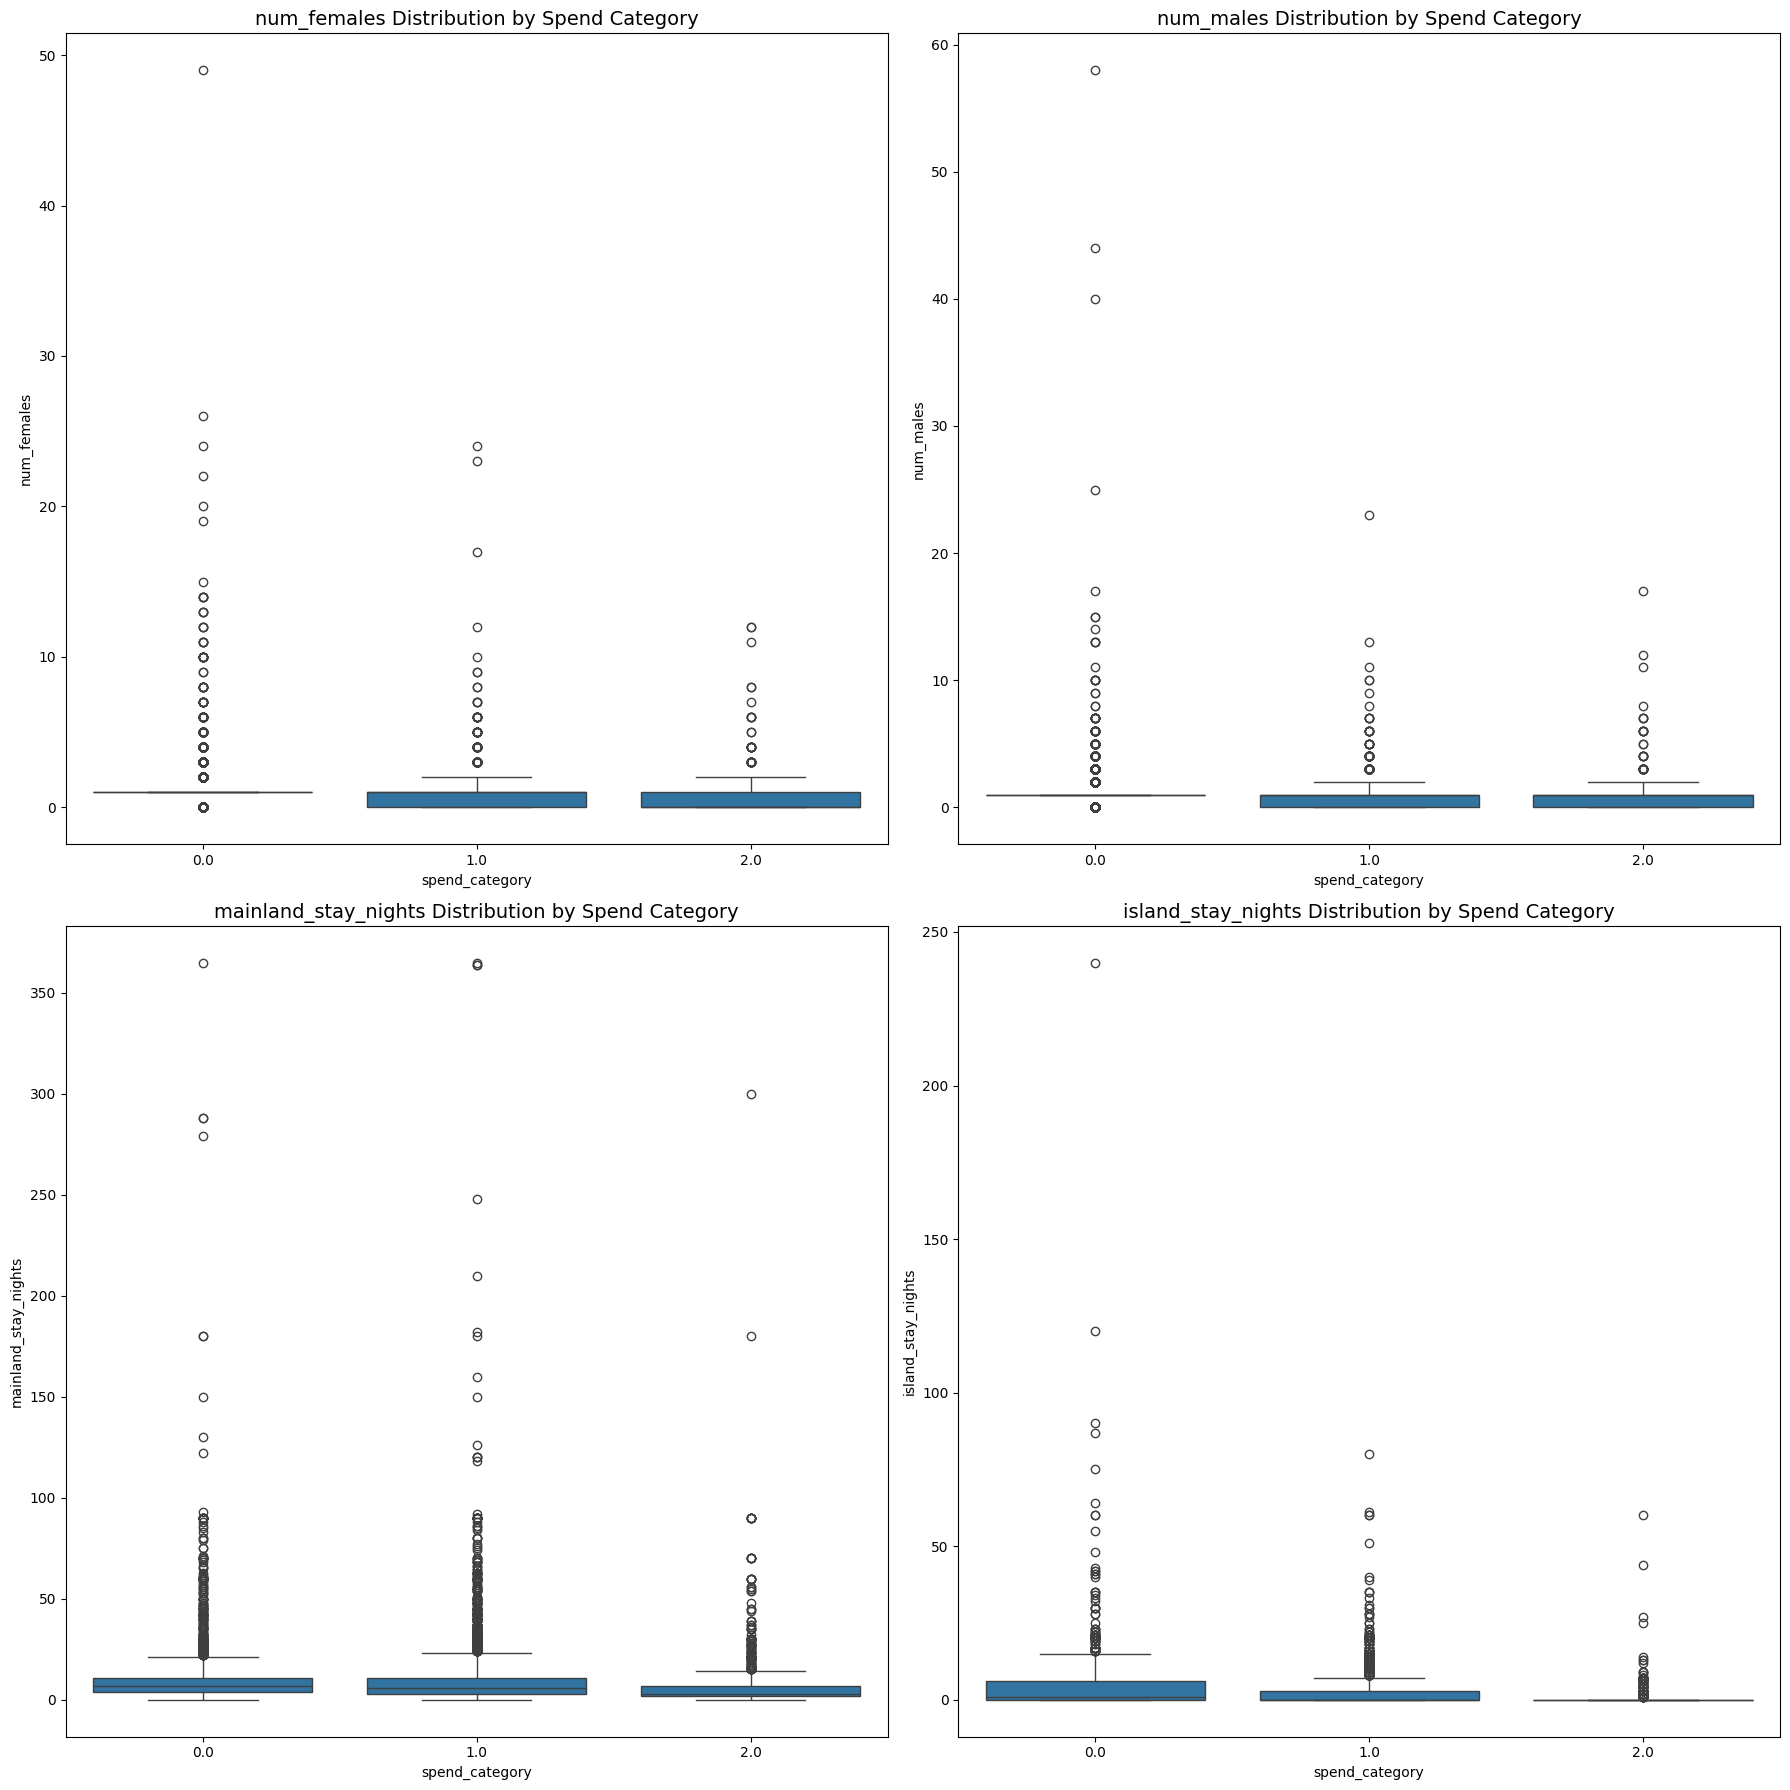

In [14]:
numeric_cols = [
    "num_females",
    "num_males",
    "mainland_stay_nights",
    "island_stay_nights"
]

plt.figure(figsize=(18, 18))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train, x="spend_category", y=col)
    plt.title(f"{col} Distribution by Spend Category", fontsize=14)

plt.tight_layout()
plt.show()


### Cross Tab Heatmaps

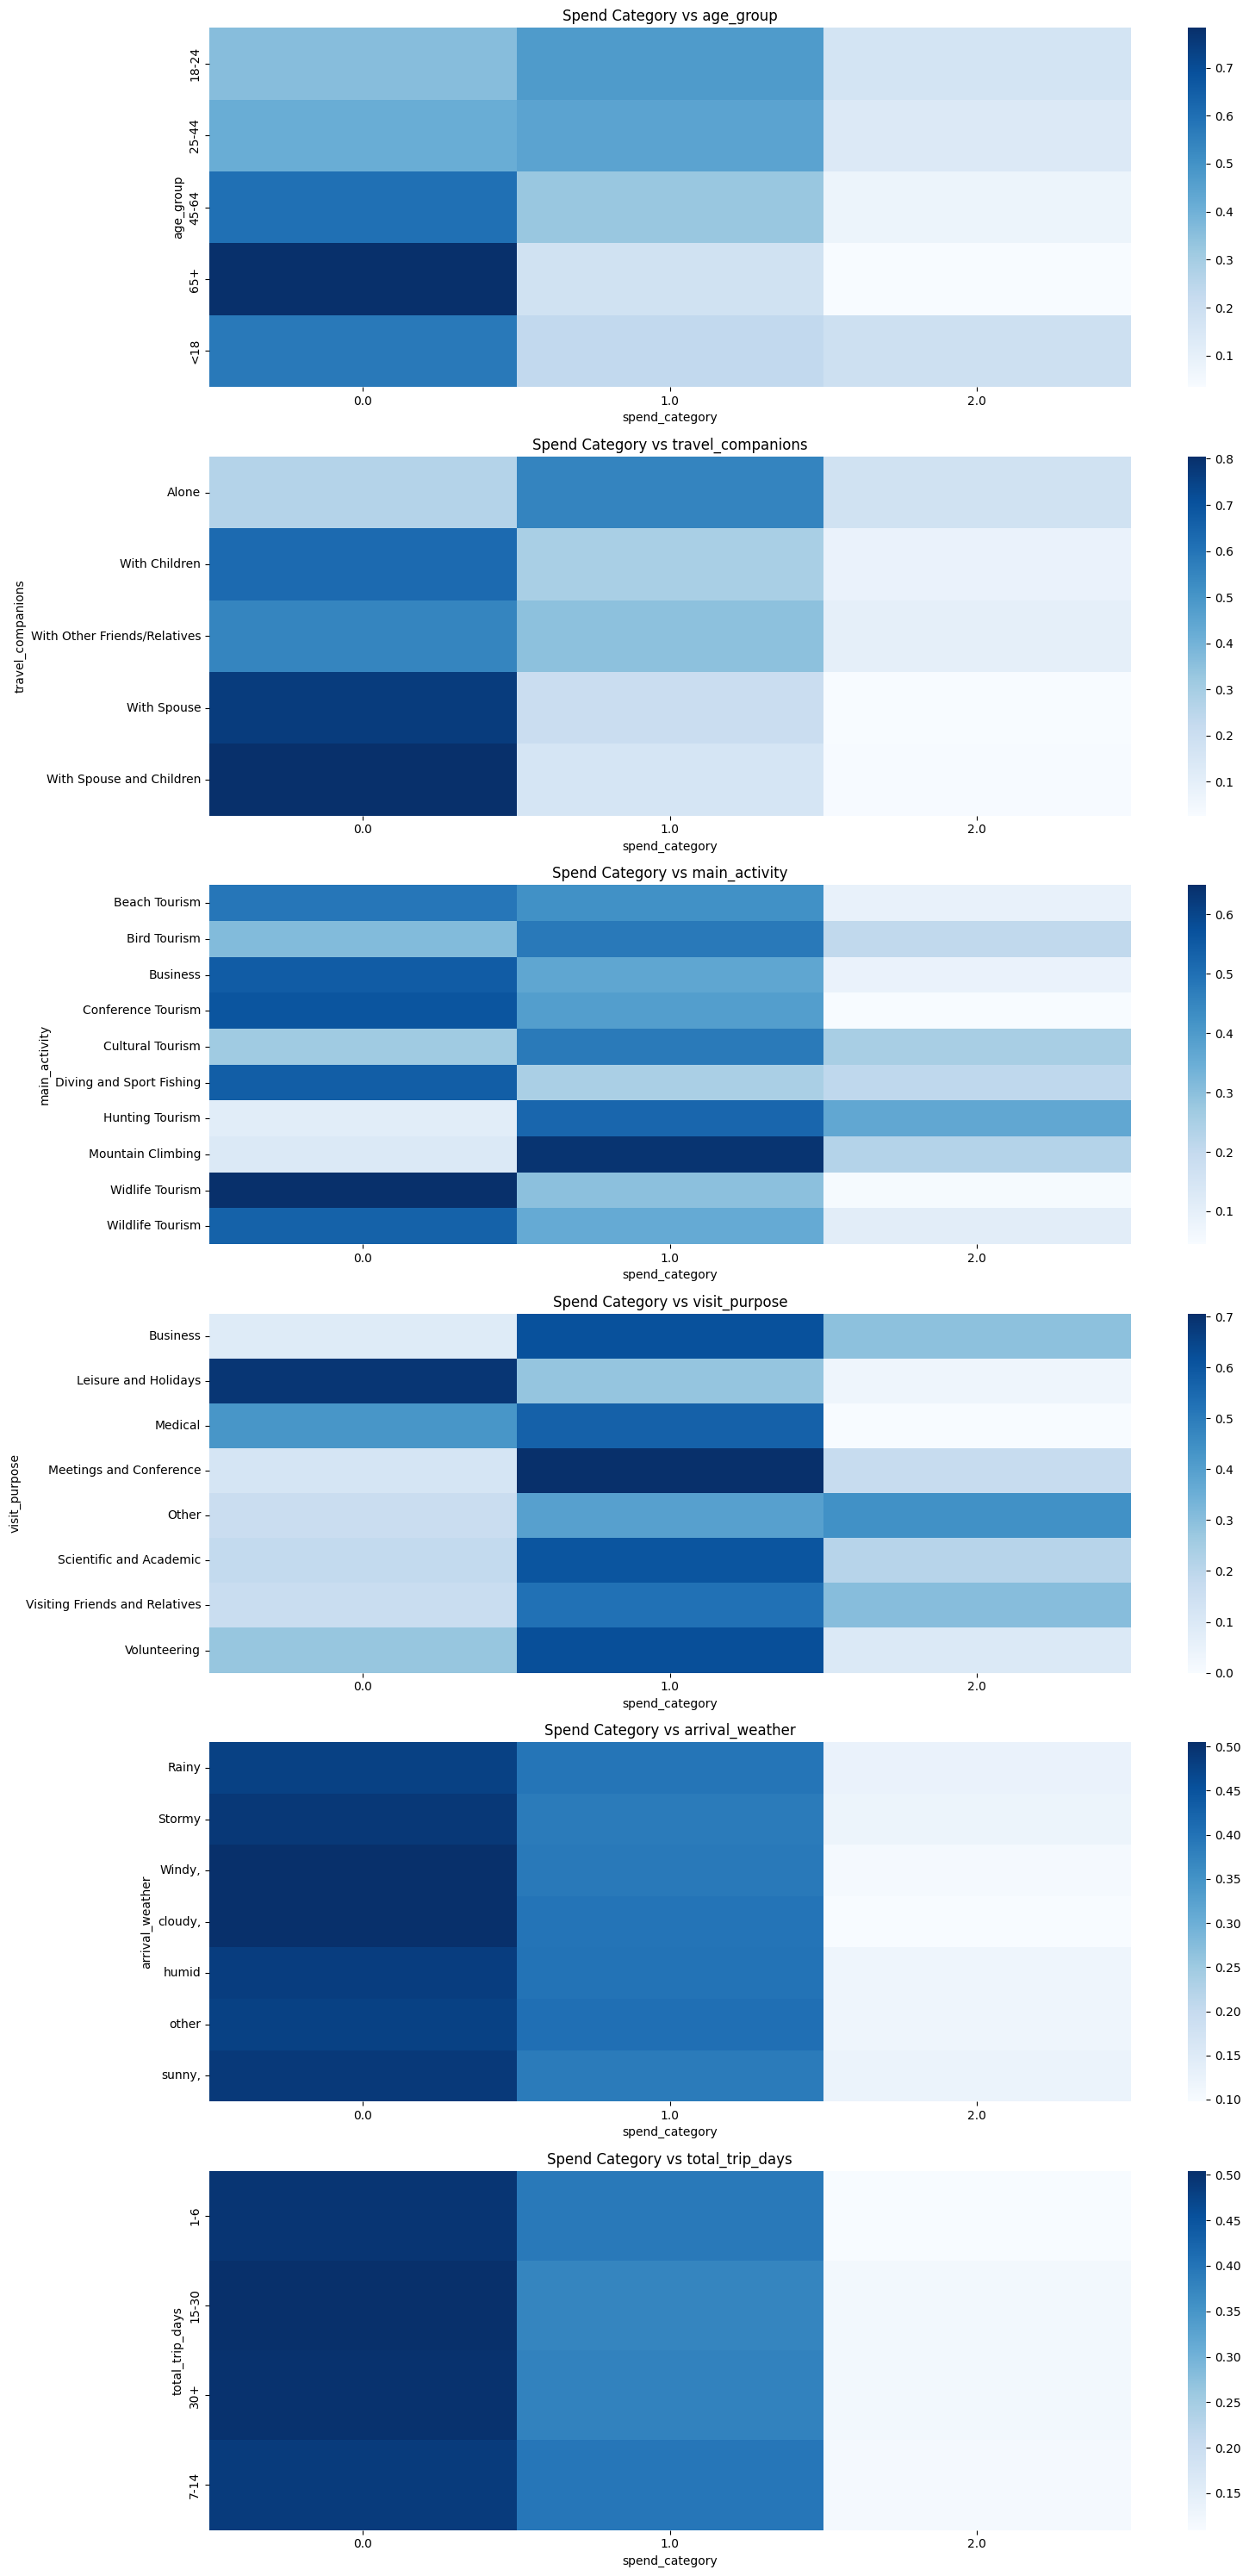

In [18]:
bivariate_cols = [
    "age_group",
    "travel_companions",
    "main_activity",
    "visit_purpose",
    "arrival_weather",
    "total_trip_days"
]

plt.figure(figsize=(16, 30))

for i, col in enumerate(bivariate_cols, 1):
    plt.subplot(len(bivariate_cols), 1, i)
    ct = pd.crosstab(train[col], train['spend_category'], normalize='index')
    sns.heatmap(ct, annot=False, cmap="Blues")
    plt.title(f"Spend Category vs {col}")

plt.tight_layout()
plt.show()
